# Goal

* Main difference is that here we're going to keep data that is not occluded so the model can learn to adjust input images (occluded) to clean images.
* Later on we're going to test different custom losses to see wether cusom loss performs better that original MSELoss.

# Data

In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [20]:
n_per_clust = 1000
img_size = 91
x = np.linspace(-4,4,img_size)
X, Y = np.meshgrid(x, x)

# two widths
widths = [1.8, 2.4]

# images and labels placeholders
images = torch.zeros(2*n_per_clust, 1, img_size, img_size)
labels = torch.zeros(2*n_per_clust)

for i in range(2*1000):
  ro = np.random.randn(2) # random offset
  G = np.exp(
      - ((X-ro[0])**2 + (Y-ro[1])**2) /
        (2*widths[i%2]**2) # every other label is odd or even due to i%2
  )

  # add noise
  G = G + np.random.randn(img_size, img_size) / 5

  # add image and label
  images[i,:,:,:] = torch.tensor(G).view(1,img_size, img_size)
  labels[i] = i%2

labels = labels[:,None]

# Occlusion

In [21]:
import copy

occ_images = copy.deepcopy(images)

# images shape: (N, C, H, W)
margin = 10

for i in range(occ_images.shape[0]):
    img = occ_images[i, 0]  # (H, W)
    H, W = img.shape

    occ_size = np.random.randint(5, 10)

    if np.random.rand() < 0.5:
        # pionowa (kolumny)
        start = np.random.randint(margin, W - occ_size - margin)
        img[:, start:start + occ_size] = 0
    else:
        # pozioma (wiersze)
        start = np.random.randint(margin, H - occ_size - margin)
        img[start:start + occ_size, :] = 0

    occ_images[i, 0] = img

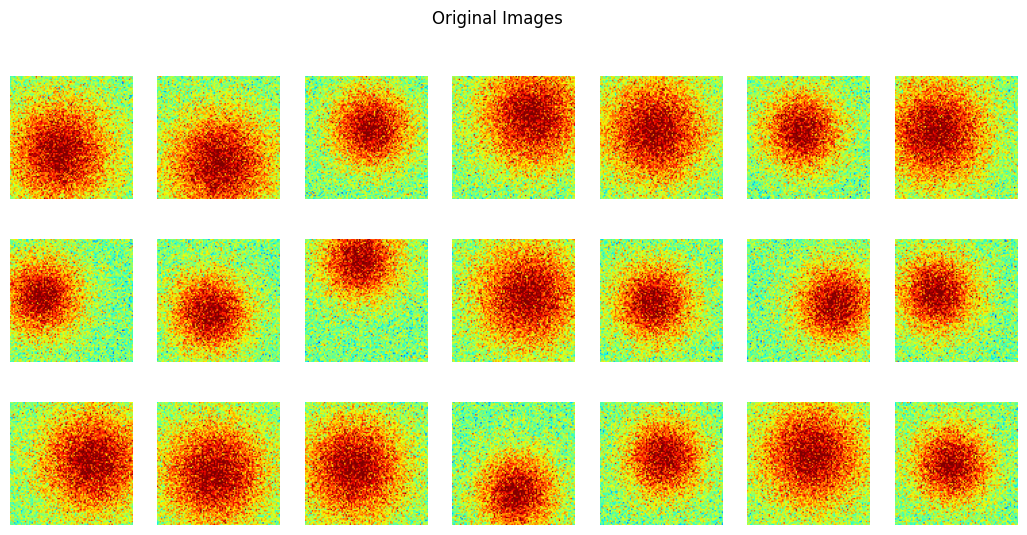

In [22]:
fig, axs = plt.subplots(3, 7, figsize = (13, 6))

for i, ax in enumerate(axs.flatten()):
  rand_row = np.random.randint(images.shape[0])
  ax.imshow(images[rand_row].squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
  ax.axis('off')
  ax.set_xticks([])
  ax.set_yticks([])

plt.suptitle('Original Images')
plt.show()

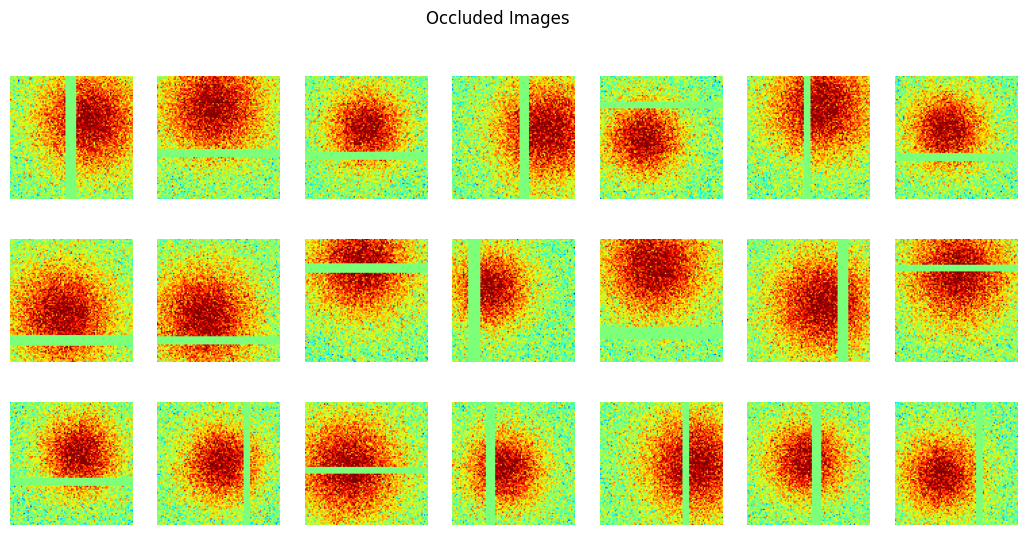

In [23]:
import copy

fig, axs = plt.subplots(3, 7, figsize = (13, 6))

for i, ax in enumerate(axs.flatten()):
  rand_row = np.random.randint(occ_images.shape[0])
  ax.imshow(occ_images[rand_row].squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
  ax.axis('off')
  ax.set_xticks([])
  ax.set_yticks([])

plt.suptitle('Occluded Images')
plt.show()

# MSELoss Model

In [24]:
def CreateModel(loss_fn):

  class CreateNet(nn.Module):
    def __init__(self):
      super().__init__()

      self.enc = nn.Sequential(
          nn.Conv2d(1, 6, 3, 1, 1),
          nn.ReLU(),
          nn.AvgPool2d(2,2),
          nn.Conv2d(6, 4, 3, 1, 1),
          nn.ReLU(),
          nn.AvgPool2d(2,2),
      )

      self.dec = nn.Sequential(
          nn.ConvTranspose2d(4, 6, 3, 2),
          nn.ReLU(),
          nn.ConvTranspose2d(6, 1, 3, 2)
      )

    def forward(self, x):
      x = self.dec(self.enc(x))
      return x

  net = CreateNet()
  loss_fn = loss_fn
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)

  return net, loss_fn, optimizer

In [25]:
def RunModel(loss_fn, epochs):

  # create a new model
  net, loss_fn, optimizer = CreateModel(loss_fn)

  # initialize losses
  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    # pick images
    pics_2_use = np.random.choice(n_per_clust, size = 32, replace = False)
    X = images[pics_2_use,:,:,:]

    occ_images = images[pics_2_use,:,:,:]

    # forward pass
    y_hat = net(X)
    loss = loss_fn(y_hat, occ_images)
    losses[epoch] = loss.item()

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch%100==0:
      print(f'Epoch: {epoch} | Loss: {loss:.3f}')

  return losses, net

In [26]:
losses_mseLoss, net_mseLoss = RunModel(loss_fn = nn.MSELoss(), epochs = 1000)

Epoch: 0 | Loss: 0.191
Epoch: 100 | Loss: 0.051
Epoch: 200 | Loss: 0.043
Epoch: 300 | Loss: 0.042
Epoch: 400 | Loss: 0.041
Epoch: 500 | Loss: 0.040
Epoch: 600 | Loss: 0.040
Epoch: 700 | Loss: 0.039
Epoch: 800 | Loss: 0.039
Epoch: 900 | Loss: 0.038


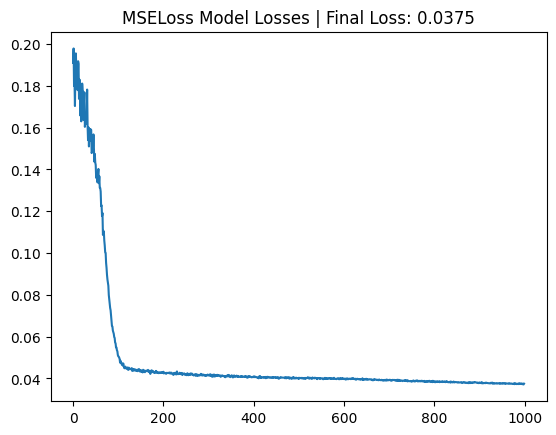

In [27]:
def plot_loss(losses, title):
  plt.plot(losses)
  plt.title(f'{title} Model Losses | Final Loss: {losses[-1]:.4f}')
  plt.show()

plot_loss(losses_mseLoss, 'MSELoss')

In [28]:
def plot_results(net, title):
  fig, axs = plt.subplots(2, 5, figsize = (10, 4))

  rand_rows = np.random.choice(images.shape[0], size = 5)
  imgs = occ_images[rand_rows]
  deocc_imgs = net(imgs)

  for i in range(5):

    axs[0][i].imshow(imgs[i].squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
    axs[0][i].axis('off')
    axs[0][i].set_xticks([])
    axs[0][i].set_yticks([])
    axs[0][i].set_title(f'Occluded {rand_rows[i]}')

    axs[1][i].imshow(deocc_imgs[i].detach().squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
    axs[1][i].axis('off')
    axs[1][i].set_xticks([])
    axs[1][i].set_yticks([])
    axs[1][i].set_title(f'Deoccluded {rand_rows[i]}')

  plt.suptitle(title, )
  plt.show()

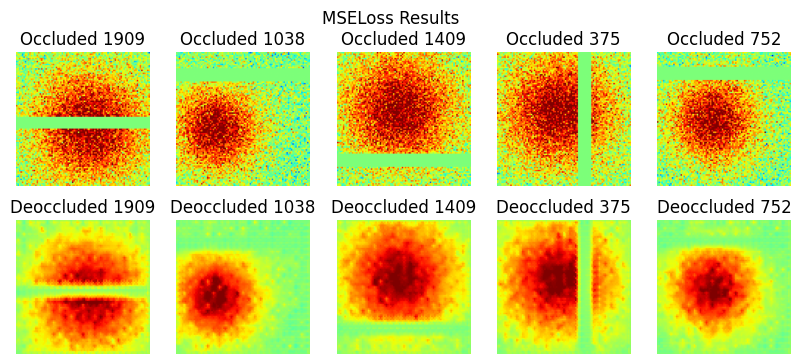

In [29]:
plot_results(net_mseLoss, 'MSELoss Results')

No significant improvement we still can see occlusion.

# MAELoss

$$ L(\widehat{y},y) = n^{-1}\sum_{i=1}^n|\widehat{y}_i - y_i| $$

In [30]:
class maeLoss(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x, y):
    mae_loss = torch.mean(
        torch.abs(x - y)
    )
    return mae_loss

In [31]:
losses_maeLoss, net_maeLoss = RunModel(loss_fn = maeLoss(), epochs = 1000)

Epoch: 0 | Loss: 0.493
Epoch: 100 | Loss: 0.168
Epoch: 200 | Loss: 0.162
Epoch: 300 | Loss: 0.160
Epoch: 400 | Loss: 0.159
Epoch: 500 | Loss: 0.158
Epoch: 600 | Loss: 0.158
Epoch: 700 | Loss: 0.157
Epoch: 800 | Loss: 0.156
Epoch: 900 | Loss: 0.155


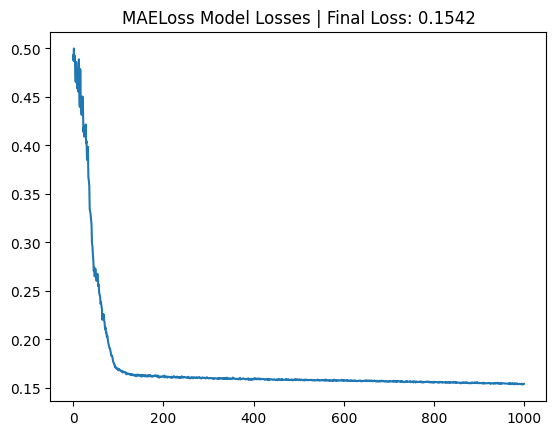

In [32]:
plot_loss(losses_maeLoss, 'MAELoss')

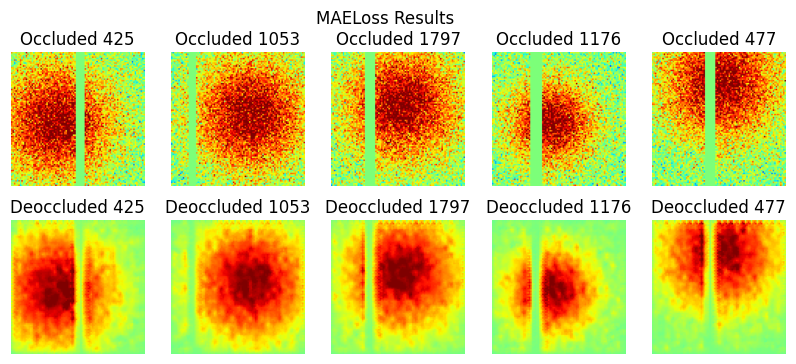

In [33]:
plot_results(net_maeLoss, 'MAELoss Results')

MAE Loss performed slightly better.

# AveLoss

$$ L(\widehat{y},y) = n^{-1}\sum_{i=1}^n (\widehat{y}_i - y_i)^2  + n^{-1} \Big| \sum_{i=1}^n \widehat{y}_i \Big|$$

In [34]:
class aveLoss(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x, y):
    mse = torch.mean((x - y)**2, dim=tuple(range(1, x.ndim)))
    mean_penalty = torch.abs(torch.mean(x, dim=tuple(range(1, x.ndim))))
    aveLoss = torch.mean(mse + mean_penalty)
    return aveLoss

In [35]:
losses_aveLoss, net_aveLoss = RunModel(loss_fn = aveLoss(), epochs = 1000)

Epoch: 0 | Loss: 0.397
Epoch: 100 | Loss: 0.240
Epoch: 200 | Loss: 0.172
Epoch: 300 | Loss: 0.181
Epoch: 400 | Loss: 0.200
Epoch: 500 | Loss: 0.190
Epoch: 600 | Loss: 0.186
Epoch: 700 | Loss: 0.196
Epoch: 800 | Loss: 0.194
Epoch: 900 | Loss: 0.187


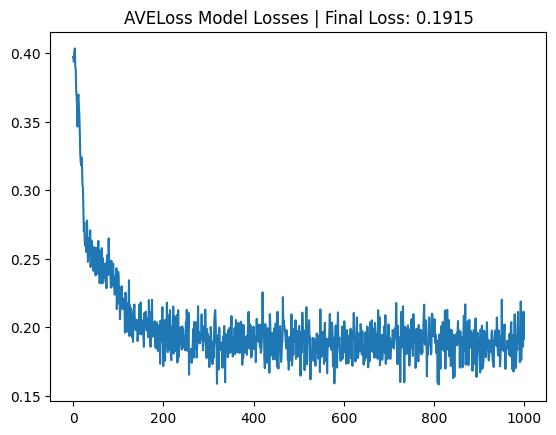

In [36]:
plot_loss(losses_aveLoss, 'AVELoss')

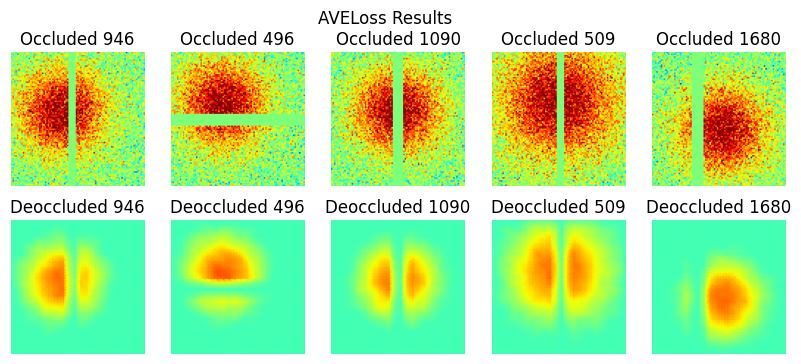

In [37]:
plot_results(net_aveLoss, 'AVELoss Results')

Image is way more disturbed but occlusion vanished on pictures where occlusion was not directly above blur.

# CorrLoss

Based on Pearson Correlation

$$ L(\widehat{y},y) = \frac{\sum{(\widehat{y}-\mu_{\widehat{y}})(y-\mu_{y})}}{(n-1)\sigma_{\widehat{y}}\sigma y} $$

In [38]:
class corrLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, x, y):
        mean_x = torch.mean(x)
        mean_y = torch.mean(y)

        num = torch.sum((x-mean_x)*(y-mean_y))
        den = (torch.numel(y)-1)*torch.std(x) * torch.std(y)

        return -num/den

In [45]:
losses_corrLoss, net_corrLoss = RunModel(loss_fn = corrLoss(), epochs = 100)

Epoch: 0 | Loss: -0.009


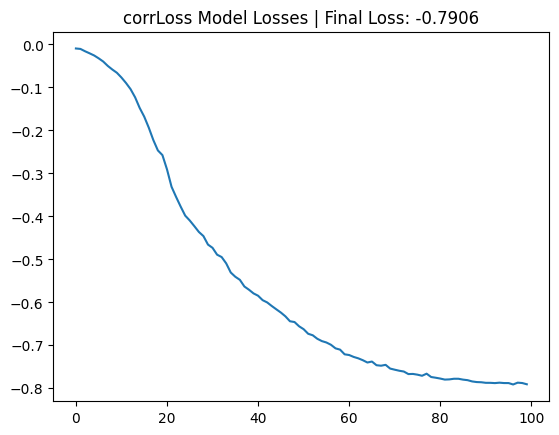

In [46]:
plot_loss(losses_corrLoss, 'corrLoss')

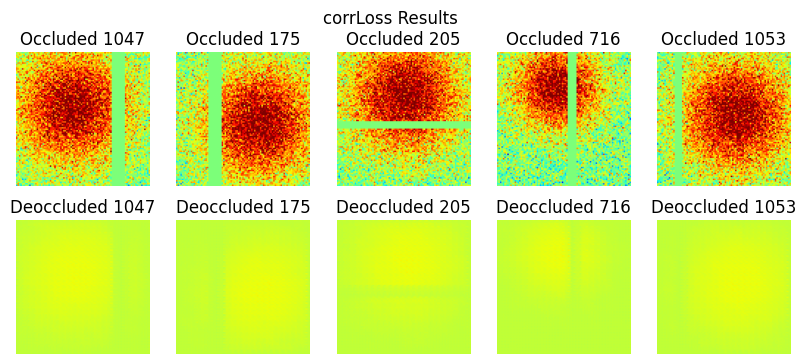

In [47]:
plot_results(net_corrLoss, 'corrLoss Results')

Correlation loss ignores absolute pixel values and cares only about matching the pattern up to scale and offset. The network can minimize the loss by outputting a nearly constant image with very low variance. This gives undefined or near-zero standard deviation, so the correlation term becomes unstable and gradients push the output toward a flat mean image. As a result, the model collapses to a uniform output that has no structure, which is exactly what you see in the deoccluded images. Correlation loss alone is therefore ill-posed for inpainting and must be combined with MSE or a variance/energy constraint to prevent this collapse.

# MaskedLoss

$$ L(\widehat{y},y) = \frac{\sum_{i=1}^{n} m_i (\hat{y}_i - y_i)^2}{\sum_{i=1}^{n} m_i} $$


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ================= DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ================= MODEL =================
class InpaintingNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU()
        )
        self.enc2 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU()
        )

        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU()
        )

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        d1 = self.dec1(e2)

        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(
                d1,
                size=e1.shape[-2:],
                mode='bilinear',
                align_corners=False
            )

        x = torch.cat([d1, e1], dim=1)
        return self.out(x)

# ================= LOSS =================
def masked_mse(pred, target, mask):
    return ((pred - target) ** 2 * mask).sum() / mask.sum()

# ================= DATA TO GPU =================
occ_images = occ_images.to(device)
images = images.to(device)

# ================= TRAIN LOOP + EARLY STOP =================
net = InpaintingNet().to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

epochs = 500
patience = 10
best_loss = float('inf')
best_state = None
counter = 0

for epoch in range(epochs):
    net.train()

    mask = (occ_images == 0).float()

    output = net(occ_images)
    loss = masked_mse(output, images, mask)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_val = loss.item()
    print(f"Epoch {epoch} | Loss {loss_val:.6f}")

    if loss_val < best_loss:
        best_loss = loss_val
        best_state = net.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# ================= RESTORE BEST =================
net.load_state_dict(best_state)
print("Best loss:", best_loss)
print("Model device:", next(net.parameters()).device)


Device: cuda
Epoch 0 | Loss 0.256010
Epoch 1 | Loss 0.229484
Epoch 2 | Loss 0.205335
Epoch 3 | Loss 0.182990
Epoch 4 | Loss 0.162375
Epoch 5 | Loss 0.143653
Epoch 6 | Loss 0.127325
Epoch 7 | Loss 0.114402
Epoch 8 | Loss 0.106277
Epoch 9 | Loss 0.104515
Epoch 10 | Loss 0.108726
Epoch 11 | Loss 0.114359
Epoch 12 | Loss 0.116776
Epoch 13 | Loss 0.115037
Epoch 14 | Loss 0.110641
Epoch 15 | Loss 0.105467
Epoch 16 | Loss 0.100800
Epoch 17 | Loss 0.097259
Epoch 18 | Loss 0.094859
Epoch 19 | Loss 0.093333
Epoch 20 | Loss 0.092306
Epoch 21 | Loss 0.091438
Epoch 22 | Loss 0.090487
Epoch 23 | Loss 0.089289
Epoch 24 | Loss 0.087778
Epoch 25 | Loss 0.086002
Epoch 26 | Loss 0.084103
Epoch 27 | Loss 0.082352
Epoch 28 | Loss 0.081045
Epoch 29 | Loss 0.080329
Epoch 30 | Loss 0.080014
Epoch 31 | Loss 0.079611
Epoch 32 | Loss 0.078743
Epoch 33 | Loss 0.077466
Epoch 34 | Loss 0.076154
Epoch 35 | Loss 0.075112
Epoch 36 | Loss 0.074417
Epoch 37 | Loss 0.073900
Epoch 38 | Loss 0.073325
Epoch 39 | Loss 0.0725

In [10]:
def plot_results(net, title):
  fig, axs = plt.subplots(2, 5, figsize = (10, 4))

  rand_rows = np.random.choice(images.shape[0], size = 5)
  imgs = occ_images[rand_rows]
  deocc_imgs = net(imgs)

  for i in range(5):

    axs[0][i].imshow(imgs[i].detach().cpu().squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
    axs[0][i].axis('off')
    axs[0][i].set_xticks([])
    axs[0][i].set_yticks([])
    axs[0][i].set_title(f'Occluded {rand_rows[i]}')

    axs[1][i].imshow(deocc_imgs[i].detach().cpu().squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
    axs[1][i].axis('off')
    axs[1][i].set_xticks([])
    axs[1][i].set_yticks([])
    axs[1][i].set_title(f'Deoccluded {rand_rows[i]}')

  plt.suptitle(title, )
  plt.show()

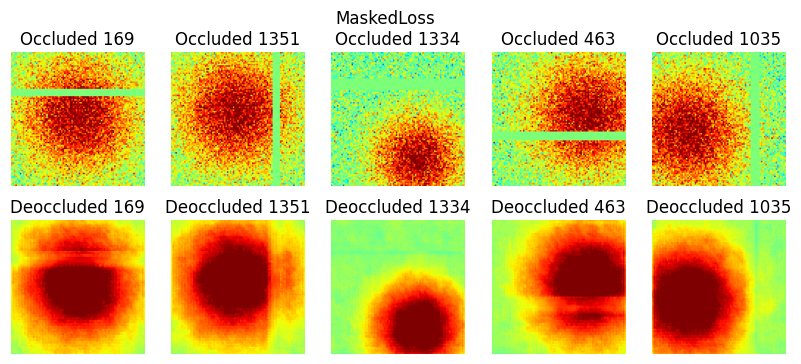

In [11]:
plot_results(net, 'MaskedLoss')

Masked loss works best because it computes error only in the occluded regions. The model is not rewarded for copying visible pixels, so all learning is focused on reconstructing missing parts. With standard MSE most pixels are already correct, so the model learns identity mapping and ignores occlusions. Masked MSE forces the network to infer structure in missing areas, which gives better inpainting results.